# Generate Figures for a Single Run

Including:
1. Coefficients
2. Left and Right Modes

In [1]:
# Import the FEMSystem Class from directory above
import sys
sys.path.append('../..')
from FEMSystem import FEMSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from jax.scipy.sparse.linalg import cg

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


'''
Fill in File Path
'''
file_path = '../allplots/sepsweep3/sep15/results.pkl'


########################################################

pickled_obj = {}
with open(file_path, 'rb') as f:
    pickled_obj= pickle.load(f)

femsystem:FEMSystem = pickled_obj["femsystem"]
femsystem.saveFigsDir = None # Turn OFF saving plots
u_even,u_odd = pickled_obj["u_even"],pickled_obj["u_odd"]

# Normalize the modes
u_even = u_even / femsystem.integrate(lambda u,a,b: u**2,u_even)
u_odd = u_odd / femsystem.integrate(lambda u,a,b: u**2,u_odd)

u_even_interior,u_odd_interior = u_even[femsystem.interior_dofs],u_odd[femsystem.interior_dofs]
u_left_interior,u_right_interior = (u_even_interior+u_odd_interior)/jnp.sqrt(2), (u_even_interior-u_odd_interior)/jnp.sqrt(2)
theta_at_dofs = pickled_obj["theta_at_dofs"]
theta_at_interior = theta_at_dofs[femsystem.interior_dofs]
n,coeffs = pickled_obj["n"],pickled_obj["coeffs"]
E_J,E_C,e_0 = pickled_obj["E_J"],pickled_obj["E_C"],pickled_obj["e0"]
parameters = pickled_obj["parameters"]
totalTime = pickled_obj["totalTime"]

material = parameters["material"]
separation = parameters["separation"]
integrated_volume = pickled_obj["integrated_volume"]
sidelenX, sidelenY, sidelenZ = parameters["sidelenX"], parameters["sidelenY"], parameters["sidelenZ"]
volume = 2 * sidelenX * sidelenY * sidelenZ
print(f"Volume Integration Error: {(integrated_volume - volume) / volume * 100:.4g}% | Integrated Volume: {integrated_volume} | Volume: {volume}")

print(f"EJ: {E_J:.4g}, EC: {E_C:.4g}, EJ/EC: {E_J/E_C:.4g} | Time: {int(totalTime // 60)}m {int(totalTime % 60)}s | Degrees of Freedom: {femsystem.dofs}")
print(f"Parameters:")
print(parameters)
centerLeft,centerRight = ((sidelenX+separation)/2,0,0), (-(sidelenX+separation)/2,0,0)

from IPython.display import display, Latex

# Prepare a full LaTeX table of all the simulation parameters
latex_table = r"""
\begin{table}[h!]
\centering
\begin{tabular}{|l|l|}
\hline
\textbf{Parameter} & \textbf{Value} \\
\hline
Material & %s \\
Separation & %.5g \\
Side Length X & %.5g \\
Side Length Y & %.5g \\
Side Length Z & %.5g \\
Integrated Volume & %.5g \\
Volume formula $2 L_x L_y L_z$ & %.5g \\
Relative Volume Error ($\\frac{V_\mathrm{int}-V}{V} \\times 100$) & %.3g\\%% \\
$E_J$ & %.5g \\
$E_C$ & %.5g \\
$E_J / E_C$ & %.5g \\
$e_0$ & %.5g \\
Degrees of Freedom & %d \\
$n$ (number of basis states) & %d \\
Total Time (s) & %.2f \\
\hline
\end{tabular}
\caption{Simulation parameters.}
\end{table}
""" % (
    str(material),
    separation,
    sidelenX,
    sidelenY,
    sidelenZ,
    integrated_volume,
    volume,
    (integrated_volume - volume) / volume * 100,
    E_J,
    E_C,
    E_J / E_C,
    e_0,
    femsystem.dofs,
    n,
    totalTime
)

# Print the raw latex (unrendered)
print(latex_table)

Volume Integration Error: 0.1677% | Integrated Volume: 8013.416015625 | Volume: 8000.0
EJ: 1.26, EC: 3.336, EJ/EC: 0.3776 | Time: 25m 20s | Degrees of Freedom: 73429
Parameters:
{'material': 0.0033784, 'separation': 15.0, 'sidelenX': 10.0, 'sidelenY': 20.0, 'sidelenZ': 20.0, 'padding': 20.0, 'gridlenX': 65.0, 'gridlenY': 60.0, 'gridlenZ': 60.0, 'lc_large': 15.0, 'lc_small': 1.0}

\begin{table}[h!]
\centering
\begin{tabular}{|l|l|}
\hline
\textbf{Parameter} & \textbf{Value} \\
\hline
Material & 0.0033784 \\
Separation & 15 \\
Side Length X & 10 \\
Side Length Y & 20 \\
Side Length Z & 20 \\
Integrated Volume & 8013.4 \\
Volume formula $2 L_x L_y L_z$ & 8000 \\
Relative Volume Error ($\\frac{V_\mathrm{int}-V}{V} \\times 100$) & 0.168\\% \\
$E_J$ & 1.2598 \\
$E_C$ & 3.3362 \\
$E_J / E_C$ & 0.37763 \\
$e_0$ & -853.19 \\
Degrees of Freedom & 73429 \\
$n$ (number of basis states) & 40 \\
Total Time (s) & 1520.01 \\
\hline
\end{tabular}
\caption{Simulation parameters.}
\end{table}



## 1. Coefficients

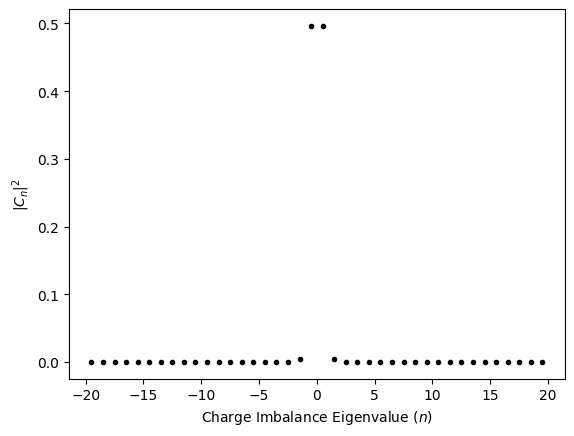

In [2]:
# Plot the coefficients of the eigenvectors, only the middle m
m = 20
x = (n-1)/2 - jnp.arange(n)

#normalize the coefficients
coeffs = (coeffs / jnp.sqrt(jnp.sum(coeffs**2)))**2

plt.plot(x[n//2-m:n//2+m],coeffs[n//2-m:n//2+m],".",color="black")
plt.xlabel(r"Charge Imbalance Eigenvalue ($n$)")
plt.ylabel(r"$|C_n|^2$")
plt.show()

## 2. Left and Right Modes

(<Figure size 800x800 with 2 Axes>,
 <Axes3D: title={'center': 'Right Mode'}>,
 <mpl_toolkits.mplot3d.art3d.Path3DCollection at 0x3438dcdf0>)

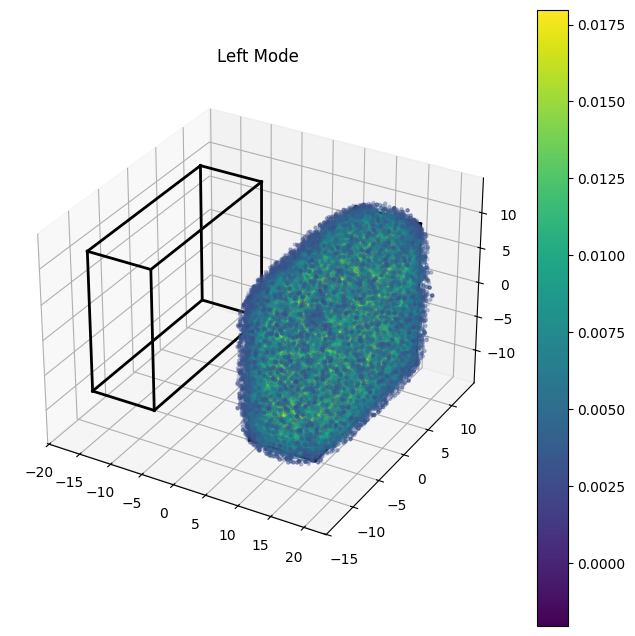

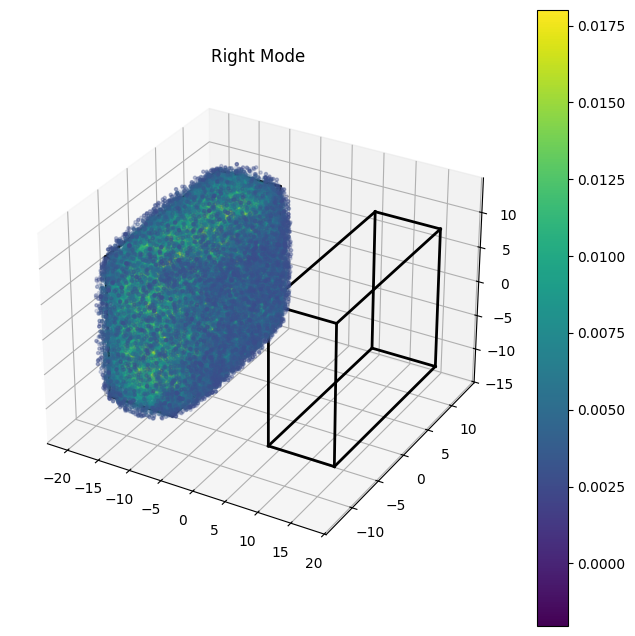

In [3]:
# Softer volumetric rendering (closer to the cloudy look in reference image 1)
threshold = 0.0025
# for sep1: 0.0025 
max_points = 50000
prism_centers = [centerLeft,centerRight]
prism_side_lengths = [(sidelenX, sidelenY, sidelenZ),(sidelenX, sidelenY, sidelenZ)]
wire_color = "black"
wire_linewidth = 2.0
opacity_power = 1.5
alpha_lo = 0.4 #Opacity of lower values, lower is more transparent
alpha_hi = 0.01 #Opacity of higher values, lower is more transparent

# LEFT mode
femsystem.plot_interior_at_quad_3d_heatmap(u_left_interior, plot_title="Left Mode", max_points=max_points,value_threshold=threshold,
    alpha_lo=alpha_lo,
    alpha_hi=alpha_hi,
    prism_centers=prism_centers,
    prism_side_lengths=prism_side_lengths,
    wire_color=wire_color,
    wire_linewidth=wire_linewidth,
    opacity_power=opacity_power
)

# RIGHT mode
femsystem.plot_interior_at_quad_3d_heatmap(u_right_interior, plot_title="Right Mode", max_points=max_points,value_threshold=threshold,
    alpha_lo=alpha_lo,
    alpha_hi=alpha_hi,
    prism_centers=prism_centers,
    prism_side_lengths=prism_side_lengths,
    wire_color=wire_color,
    wire_linewidth=wire_linewidth,
    opacity_power=opacity_power
)


In [1]:
#  Qubit Frequency

 # Assume that half charge imbalance is perfectly centered around 0
# So odd n: -1 0 1 in middle, even n: -0.5 0.5 in middle
def eigensolver(n,E_J,E_C):
    # Construct charge imbalance Eigenvalues
    charge_imbalance_eigenvalues = (n-1)/2 - jnp.arange(n)

    # Construct Discrete Hamiltonian Matrix
    def Jz2(n):
        j = (n-1)/2
        diagonals = j - jnp.arange(n)
        return jnp.diag(diagonals**2)
    def off_diag(n,k):
        ones_super, ones_sub = jnp.ones(n - k, dtype=jnp.int32),jnp.ones(n - k, dtype=jnp.int32)
        super_diag_matrix,sub_diag_matrix= jnp.diag(ones_super, k=k),jnp.diag(ones_sub, k=-1*k)
        result = super_diag_matrix + sub_diag_matrix
        return result 
    def cos_phi(n):
        return off_diag(n,1) / 2
    hamiltonian = E_C * Jz2(n) - E_J * cos_phi(n) # No need for e_0 term, since we are only interested in eigenvectors

    # Find Eigenvalues and Eigenvectors
    eigenvalues,eigenvectors = jnp.linalg.eigh(hamiltonian)

    # Normalize eigenvectors
    eigenvectors = eigenvectors / jnp.sqrt(jnp.sum(jnp.abs(eigenvectors)**2, axis=0, keepdims=True))
    return hamiltonian, eigenvectors, eigenvalues, charge_imbalance_eigenvalues

hamiltonian, eigenvectors, eigenvalues, charge_imbalance_eigenvalues = eigensolver(n,E_J,E_C)
print(eigenvalues[1]-eigenvalues[0])

NameError: name 'n' is not defined

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def get_quad_cloud(femsystem, u_interior, value_threshold=None, max_points=50000):
    u_global = femsystem._get_u_from_interior(u_interior)
    u_quad = femsystem._interpolate_values(u_global)
    coords = np.asarray(femsystem.coords_q_T).reshape(3, -1)
    vals = np.asarray(u_quad).ravel()

    if value_threshold is not None:
        m = np.abs(vals) > value_threshold
        coords, vals = coords[:, m], vals[m]

    if coords.shape[1] > max_points:
        idx = np.random.choice(coords.shape[1], max_points, replace=False)
        coords, vals = coords[:, idx], vals[idx]

    return coords, vals

# 1) Build datasets from 4 different FEMSystems
datasets = [
    get_quad_cloud(fs1, u1),
    get_quad_cloud(fs2, u2),
    get_quad_cloud(fs3, u3),
    get_quad_cloud(fs4, u4),
]

# 2) Global normalization across all 4
all_vals = np.concatenate([v for _, v in datasets])
vmin, vmax = np.percentile(all_vals, [1, 99])   # robust; or min/max
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = "viridis"

fig = plt.figure(figsize=(10, 6), constrained_layout=True)
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.9])

ax_a = fig.add_subplot(gs[0, 0], projection="3d")
ax_b = fig.add_subplot(gs[0, 1], projection="3d")
ax_d = fig.add_subplot(gs[1, 0], projection="3d")
ax_e = fig.add_subplot(gs[1, 1], projection="3d")
ax_c = fig.add_subplot(gs[0, 2])   # coeff plot 1
ax_f = fig.add_subplot(gs[1, 2])   # coeff plot 2

heat_axes = [ax_a, ax_b, ax_d, ax_e]
mappable_ref = None
for ax, (coords, vals) in zip(heat_axes, datasets):
    sc = ax.scatter(coords[0], coords[1], coords[2], c=vals, s=4, cmap=cmap, norm=norm, alpha=0.9)
    if mappable_ref is None:
        mappable_ref = sc
    # optional: same view/limits
    # ax.view_init(elev=25, azim=-60)

# single shared colorbar for heatmaps only
cbar = fig.colorbar(mappable_ref, ax=heat_axes, location="right", shrink=0.9, pad=0.03)
cbar.set_label(r"$|u|^2$")  # or your quantity

# coefficient panels
ax_c.plot(x1, y1, ".")
ax_f.plot(x2, y2, ".")

# labels: top-left
for ax, lab in zip([ax_a, ax_b, ax_c, ax_d, ax_e, ax_f], ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]):
    if hasattr(ax, "text2D"):  # 3D axes
        ax.text2D(0.02, 0.98, lab, transform=ax.transAxes, ha="left", va="top", fontweight="bold")
    else:
        ax.text(0.02, 0.98, lab, transform=ax.transAxes, ha="left", va="top", fontweight="bold")

fig.savefig("paper_fig_modes_coeffs.pdf", bbox_inches="tight")

NameError: name 'fs1' is not defined